In [1]:
options(repr.plot.width = 7, repr.plot.height = 4)  # reset if needed


In [2]:
library(dplyr)
library(lme4)

merged_data <- read.delim(
  #"/home/mjehangir/telomere-sv-analysis/data/somatic_SV_CNV_TEL_merged_data.tsv",
      "/home/mjehangir/telomere-sv-analysis/data/aysa_SVs/aysa_somatic_SV_CNV_TEL_merged_data.tsv",

  sep = "\t", header = TRUE, stringsAsFactors = FALSE, check.names = FALSE
)

dim(merged_data)
head(merged_data)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix



[1] 1540   24

,filename,chr,Arm,arm_size.y,type,sv_count,sv_size_sum,chr_arm_length_mb,sv_rate,sv_proportion,⋯,final_average_TL_p75_kb,direction,TL_group,TL_kb,log_sv_rate,log_sv_prop,log_rate,has_sv,TL_scaled,arm_size_scaled
,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1,2436A,chr1,p,124048267,BND,1,0.000000,124.04827,0.008061378,0.000000e+00,⋯,5.221000,Negative,Other,5.221000,-1.942610,-6.000000,-2.088236,1,0.09769090,1.3525406
2,2436A,chr1,p,124048267,DUP,2,0.032036,124.04827,0.016122756,2.582543e-04,⋯,5.221000,Negative,Other,5.221000,-1.710542,-3.586274,-1.789875,1,0.09769090,1.3525406
3,2436A,chr1,p,124048267,INS,4,0.000000,124.04827,0.032245513,0.000000e+00,⋯,5.221000,Negative,Other,5.221000,-1.448588,-6.000000,-1.490186,1,0.09769090,1.3525406
4,2436A,chr1,q,124339061,BND,2,0.000000,124.33906,0.016085050,0.000000e+00,⋯,5.051167,Negative,Other,5.051167,-1.711384,-6.000000,-1.790886,1,0.01152315,1.3606735
5,2436A,chr1,q,124339061,DEL,1,0.026438,124.33906,0.008042525,2.126283e-04,⋯,5.051167,Negative,Other,5.051167,-1.943328,-3.670341,-2.089241,1,0.01152315,1.3606735
6,2436A,chr10,p,40649191,DEL,1,0.003151,40.64919,0.024600736,7.751692e-05,⋯,3.611750,Negative,Other,3.611750,-1.553586,-4.105037,-1.607290,1,-0.71878869,-0.9799644


In [3]:
unique(merged_data$TL_group)
# To count how many unique samples there are
length(unique(merged_data$filename))

[1] "Other"    "Short TL"

[1] 20

In [4]:
head(merged_data)

,filename,chr,Arm,arm_size.y,type,sv_count,sv_size_sum,chr_arm_length_mb,sv_rate,sv_proportion,⋯,final_average_TL_p75_kb,direction,TL_group,TL_kb,log_sv_rate,log_sv_prop,log_rate,has_sv,TL_scaled,arm_size_scaled
,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1,2436A,chr1,p,124048267,BND,1,0.000000,124.04827,0.008061378,0.000000e+00,⋯,5.221000,Negative,Other,5.221000,-1.942610,-6.000000,-2.088236,1,0.09769090,1.3525406
2,2436A,chr1,p,124048267,DUP,2,0.032036,124.04827,0.016122756,2.582543e-04,⋯,5.221000,Negative,Other,5.221000,-1.710542,-3.586274,-1.789875,1,0.09769090,1.3525406
3,2436A,chr1,p,124048267,INS,4,0.000000,124.04827,0.032245513,0.000000e+00,⋯,5.221000,Negative,Other,5.221000,-1.448588,-6.000000,-1.490186,1,0.09769090,1.3525406
4,2436A,chr1,q,124339061,BND,2,0.000000,124.33906,0.016085050,0.000000e+00,⋯,5.051167,Negative,Other,5.051167,-1.711384,-6.000000,-1.790886,1,0.01152315,1.3606735
5,2436A,chr1,q,124339061,DEL,1,0.026438,124.33906,0.008042525,2.126283e-04,⋯,5.051167,Negative,Other,5.051167,-1.943328,-3.670341,-2.089241,1,0.01152315,1.3606735
6,2436A,chr10,p,40649191,DEL,1,0.003151,40.64919,0.024600736,7.751692e-05,⋯,3.611750,Negative,Other,3.611750,-1.553586,-4.105037,-1.607290,1,-0.71878869,-0.9799644


In [5]:
#install.packages("clubSandwich")

In [6]:
# Load necessary libraries
library(lme4)      # For mixed-effects models
library(lmerTest)  # For p-values in lmer
library(ggplot2)   # For plotting
library(ggpubr)    # For Nature-style statistical brackets
library(dplyr)     # For data manipulation

# 1. Data Preparation
# We use log10 transformation because SV rates are usually heavily right-skewed.
# We add a small constant (offset) to handle arms with 0 SVs.
offset <- min(merged_data$sv_rate[merged_data$sv_rate > 0]) / 2
merged_data$log_sv_rate <- log10(merged_data$sv_rate + offset) + merged_data$sv_proportion

# 2. Fit the Linear Mixed-Effects Model (LMM)
# Formula: log_sv_rate ~ TL_group + (1 | filename)
# (1 | filename) accounts for the random intercept of each patient
model <- lmer(log_sv_rate ~ TL_group + (1 | filename), data = merged_data)

# 3. View Results
model_summary <- summary(model)
print(model_summary)

# 4. Extract P-value for the TL_group effect
p_val <- model_summary$coefficients["TL_groupShort TL", "Pr(>|t|)"]
cat("P-value for Short TL vs Other:", p_val, "\n")


Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: log_sv_rate ~ TL_group + (1 | filename)
   Data: merged_data

REML criterion at convergence: 6269.3

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-0.7652 -0.2899 -0.0989  0.1478 25.0047 

Random effects:
 Groups   Name        Variance Std.Dev.
 filename (Intercept) 0.03149  0.1775  
 Residual             3.40005  1.8439  
Number of obs: 1540, groups:  filename, 20

Fixed effects:
                 Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)      -1.21907    0.06896 18.74114 -17.678 3.83e-13 ***
TL_groupShort TL  0.38823    0.15391 18.60860   2.522   0.0209 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
TL_grpShrTL -0.448
P-value for Short TL vs Other: 0.02094417 


In [7]:
# 1. Data Preparation: Creating the Composite Index
merged_data <- merged_data %>%
  mutate(
    # Log transform the rate
    log_rate = log10(sv_rate + (min(sv_rate[sv_rate > 0]) / 2)),
    # Scale both to Z-scores (mean=0, sd=1)
    z_rate = as.numeric(scale(log_rate)),
    z_prop = as.numeric(scale(sv_proportion)),
    # Create the Composite Index
    GII_score = (z_rate + z_prop) / 2
  )

# 2. Fit the Linear Mixed-Effects Model (LMM)
# We use GII_score as the dependent variable
#model_combined <- lmer(log10(GII_score + 1)  ~ TL_group + (1 | filename), data = merged_data)
model_combined <- lmer(log10(GII_score + 1)  ~ TL_group + (1 | filename), data = merged_data)

# 3. View Results
model_summary <- summary(model_combined)
print(model_summary)

# 4. Extract Results
p_val <- model_summary$coefficients["TL_groupShort TL", "Pr(>|t|)"]
estimate <- model_summary$coefficients["TL_groupShort TL", "Estimate"]

cat("Combined Index P-value:", p_val, "\n")
cat("Effect Size (Z-score shift):", estimate, "\n")

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: log10(GII_score + 1) ~ TL_group + (1 | filename)
   Data: merged_data

REML criterion at convergence: 168.2

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.5347 -0.6956  0.1142  0.8320  5.2760 

Random effects:
 Groups   Name        Variance Std.Dev.
 filename (Intercept) 0.002822 0.05312 
 Residual             0.063662 0.25231 
Number of obs: 1540, groups:  filename, 20

Fixed effects:
                 Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)      -0.09276    0.01513 17.94763  -6.130 8.76e-06 ***
TL_groupShort TL  0.07595    0.03381 17.89499   2.246   0.0376 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
TL_grpShrTL -0.448
Combined Index P-value: 0.03755751 
Effect Size (Z-score shift): 0.07594594 


In [8]:
# 1. Calculate the T-test P-value on the RAW GII_score (as you requested)
t_test_result <- t.test(GII_score ~ TL_group, data = merged_data)
t_p_val <- t_test_result$p.value

# 2. Format the labels
label_t   <- paste0("T-test: p = ", format.pval(t_p_val, digits = 3))
label_lmm <- "LMM: p = 0.033 (Corrected)"

# 4. Create the Plot
ggplot(merged_data, aes(x = TL_group, y = log10(GII_score + 1), fill = TL_group)) +
  # Boxplot for the distribution
  geom_boxplot(outlier.shape = NA, alpha = 0.7, width = 0.5) +
  # Jitter for raw data
  geom_jitter(width = 0.2, alpha = 0.3, size = 1, color = "#2c3e50") +
  # 2. Add T-test Label (Top)
  annotate("text", x = 1.5, 
           y = max(log10(merged_data$GII_score + shift_constant)) * 0.98, 
           label = label_t, size = 4) +
  scale_fill_manual(values = c("Other" = "#bdc3c7", "Short TL" = "#e67e22")) +
  labs(x = "Telomere Status", 
       y = "Log10(GII Score + 1)", # Be transparent about the axis
       title = "Integrated Genomic Impact of Telomere Attrition",
       caption = "*Y-axis is log-transformed to visualize outliers") +
  theme_classic(base_size = 14) +
  theme(legend.position = "none")

ERROR: Error: object 'shift_constant' not found


In [9]:
head(merged_data)

,filename,chr,Arm,arm_size.y,type,sv_count,sv_size_sum,chr_arm_length_mb,sv_rate,sv_proportion,⋯,TL_kb,log_sv_rate,log_sv_prop,log_rate,has_sv,TL_scaled,arm_size_scaled,z_rate,z_prop,GII_score
,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2436A,chr1,p,124048267,BND,1,0.000000,124.04827,0.008061378,0.000000e+00,⋯,5.221000,-1.942610,-6.000000,-1.942610,1,0.09769090,1.3525406,-1.3240444,-0.09301891,-0.7085317
2,2436A,chr1,p,124048267,DUP,2,0.032036,124.04827,0.016122756,2.582543e-04,⋯,5.221000,-1.710284,-3.586274,-1.710542,1,0.09769090,1.3525406,-0.8486595,-0.09286692,-0.4707632
3,2436A,chr1,p,124048267,INS,4,0.000000,124.04827,0.032245513,0.000000e+00,⋯,5.221000,-1.448588,-6.000000,-1.448588,1,0.09769090,1.3525406,-0.3120537,-0.09301891,-0.2025363
4,2436A,chr1,q,124339061,BND,2,0.000000,124.33906,0.016085050,0.000000e+00,⋯,5.051167,-1.711384,-6.000000,-1.711384,1,0.01152315,1.3606735,-0.8503838,-0.09301891,-0.4717013
5,2436A,chr1,q,124339061,DEL,1,0.026438,124.33906,0.008042525,2.126283e-04,⋯,5.051167,-1.943116,-3.670341,-1.943328,1,0.01152315,1.3606735,-1.3255153,-0.09289377,-0.7092045
6,2436A,chr10,p,40649191,DEL,1,0.003151,40.64919,0.024600736,7.751692e-05,⋯,3.611750,-1.553508,-4.105037,-1.553586,1,-0.71878869,-0.9799644,-0.5271382,-0.09297329,-0.3100557


In [10]:
unique(merged_data$TL_group)

[1] "Other"    "Short TL"

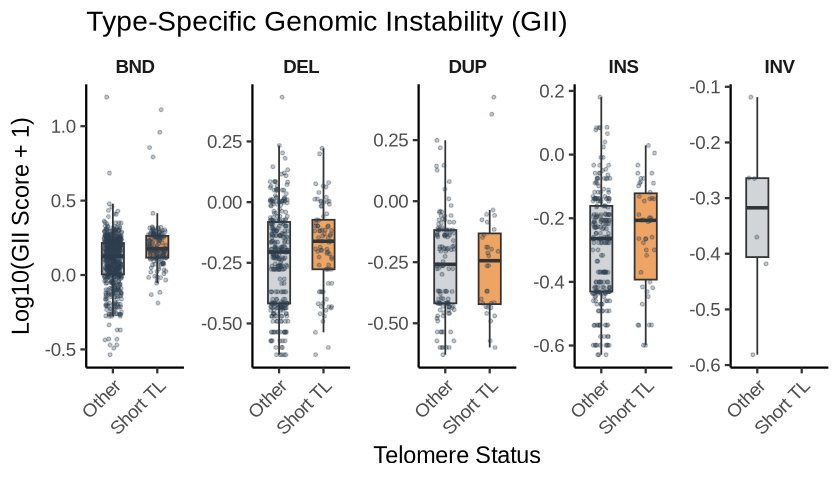

In [11]:
# 1. Ensure the column name matches your data (change 'types' to 'type')
# 2. Add the LMM p-values for each type (from your type_stats table)

ggplot(merged_data, aes(x = TL_group, y = log10(GII_score + 1), fill = TL_group)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7, width = 0.5) +
  geom_jitter(width = 0.2, alpha = 0.3, size = 0.8, color = "#2c3e50") +
  
  # Change 'types' to 'type' here
  facet_wrap(~type, scales = "free_y", nrow = 1) + 
  
  scale_fill_manual(values = c("Other" = "#bdc3c7", "Short TL" = "#e67e22")) +
  labs(x = "Telomere Status", 
       y = "Log10(GII Score + 1)",
       title = "Type-Specific Genomic Instability (GII)") +
  theme_classic(base_size = 14) +
  theme(strip.background = element_blank(), 
        strip.text = element_text(face = "bold"),
        legend.position = "none",
        axis.text.x = element_text(angle = 45, hjust = 1))

In [12]:
# Load libraries
library(lme4)
library(lmerTest)
library(dplyr)
library(purrr)
library(broom.mixed) # For tidy model outputs

# 1. Run the model for each SV type automatically
type_stats_table <- merged_data %>%
  group_by(type) %>%
  # Filter out types that don't have enough data in both groups
  filter(n_distinct(TL_group) == 2) %>%
  do(tidy(lmer (GII_score  ~ TL_group + (1 | filename), data = .), conf.int = TRUE)) %>%
  #do(tidy(lmer(log10(GII_score + 1) ~ TL_group + (1 | filename), data = .), conf.int = TRUE)) %>%

  # Filter for only the 'Short TL' effect row
  filter(term == "TL_groupShort TL") %>%
  select(type, estimate, std.error, p.value, conf.low, conf.high)

# 2. View the results
print(type_stats_table)

# A tibble: 4 × 6
# Groups:   type [4]
  type  estimate std.error p.value conf.low conf.high
  <chr>    <dbl>     <dbl>   <dbl>    <dbl>     <dbl>
1 BND     0.391     0.199   0.0662  -0.0290     0.810
2 DEL     0.0529    0.0402  0.216   -0.0361     0.142
3 DUP     0.0642    0.0705  0.379   -0.0878     0.216
4 INS     0.0390    0.0424  0.368   -0.0491     0.127


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


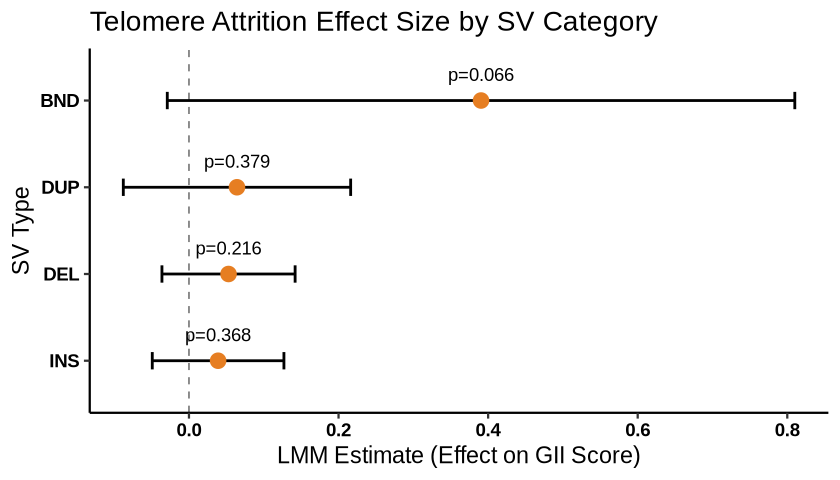

In [13]:
# Creating a publication-ready Forest Plot of the estimates
ggplot(type_stats_table, aes(x = estimate, y = reorder(type, estimate))) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50") +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0.2, size = 0.8) +
  geom_point(size = 4, color = "#e67e22") +
  # Add the p-value text next to the points
  geom_text(aes(label = paste0("p=", round(p.value, 3))), vjust = -1.5) +
  labs(x = "LMM Estimate (Effect on GII Score)", 
       y = "SV Type",
       title = "Telomere Attrition Effect Size by SV Category") +
  theme_classic(base_size = 14) +
  theme(axis.text = element_text(color = "black", face = "bold"))

In [30]:
library(broom.mixed) # Ensure this is loaded for tidy()

# 1. Get the original LMM stats with a safety filter
original_lmm_stats <- merged_data %>%
  group_by(type) %>%
  # Safety: only run model if both 'Short TL' and 'Other' exist for this type
  filter(n_distinct(TL_group) >= 2) %>%
  do(tidy(lmer(log10(GII_score + 1) ~ TL_group + (1 | filename), data = .), conf.int = TRUE)) %>%
  filter(term == "TL_groupShort TL") %>%
  select(type, estimate, conf.low, conf.high)

# 2. Merge with your Permutation P-values
final_plot_data <- left_join(original_lmm_stats, global_perm_results, by = "type")

boundary (singular) fit: see help('isSingular')



ERROR: Error: object 'global_perm_results' not found


In [31]:
ggplot(final_plot_data, aes(x = estimate, y = reorder(type, estimate))) +
  # Vertical line at 0 (No effect)
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50") +
  
  # Horizontal Error Bars (Whiskers)
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), 
                 height = 0.2, size = 0.8, color = "#2c3e50") +
  
  # Points (Color-coded by Permutation Significance)
  geom_point(aes(color = p_perm < 0.05), size = 5) +
  
  # Add Permutation P-value labels
  geom_text(aes(label = ifelse(p_perm == 0, "p < 0.001", paste0("p = ", round(p_perm, 3)))), 
            vjust = -1.5, fontface = "bold", size = 4) +
  
  # Styling and Colors
  scale_color_manual(values = c("TRUE" = "#e67e22", "FALSE" = "#bdc3c7")) +
  labs(x = "LMM Estimate (Effect Size)", 
       y = "Structural Variant Type",
       title = "Telomere-Driven Genomic Instability",
       subtitle = "Estimates & CIs from LMM; Significance from 1,000 Permutations") +
  theme_classic(base_size = 14) +
  theme(legend.position = "none",
        axis.text = element_text(color = "black", face = "bold"))

ERROR: Error: object 'final_plot_data' not found


boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



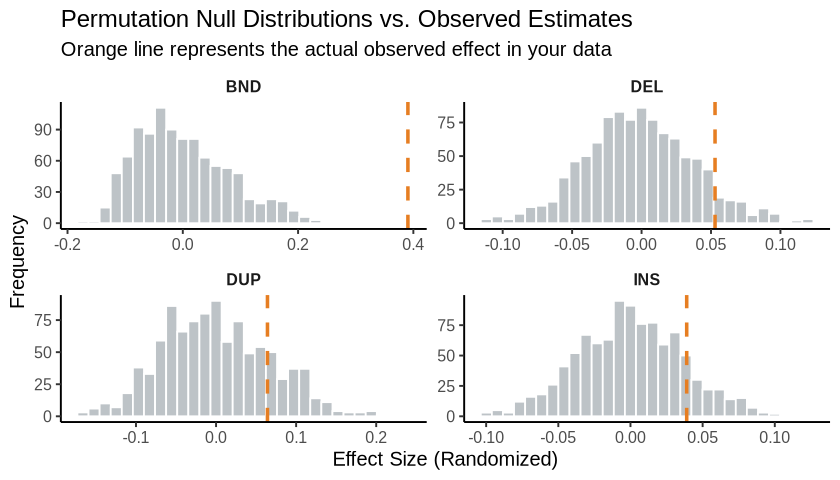

In [32]:
# 1. Run permutations and store ALL estimates for plotting
all_perm_plots_data <- merged_data %>%
  group_by(type) %>%
  filter(n_distinct(TL_group) >= 2) %>%
  do({
    sub_data <- .
    obs_mod <- lmer(GII_score ~ TL_group + (1 | filename), data = sub_data)
      #obs_mod <- lmer(log10(GII_score + 1) ~ TL_group + (1 | filename), data = sub_data)
    obs_est <- summary(obs_mod)$coefficients["TL_groupShort TL", "Estimate"]
    
    # Store 1000 shuffles
    perm_estimates <- replicate(1000, {
      sub_data$shuffled_TL <- sample(sub_data$TL_group)
      p_mod <- try(lmer(GII_score ~ shuffled_TL + (1 | filename), data = sub_data), silent = TRUE)
      if(!inherits(p_mod, "try-error")) summary(p_mod)$coefficients["shuffled_TLShort TL", "Estimate"] else NA
    })
    
    data.frame(type = unique(sub_data$type), 
               perm_est = perm_estimates, 
               obs_est = obs_est)
  })

# 2. Create the Faceted Histogram
ggplot(all_perm_plots_data, aes(x = perm_est)) +
  # The Null Distribution
  geom_histogram(bins = 30, fill = "#bdc3c7", color = "white") +
  # The Observed Reality
  geom_vline(aes(xintercept = obs_est), color = "#e67e22", linetype = "dashed", size = 1) +
  # Facet by SV Type
  facet_wrap(~type, scales = "free") +
  labs(title = "Permutation Null Distributions vs. Observed Estimates",
       subtitle = "Orange line represents the actual observed effect in your data",
       x = "Effect Size (Randomized)",
       y = "Frequency") +
  theme_classic(base_size = 12) +
  theme(strip.background = element_blank(),
        strip.text = element_text(face = "bold"))

In [33]:
#model validation

`geom_smooth()` using formula = 'y ~ x'


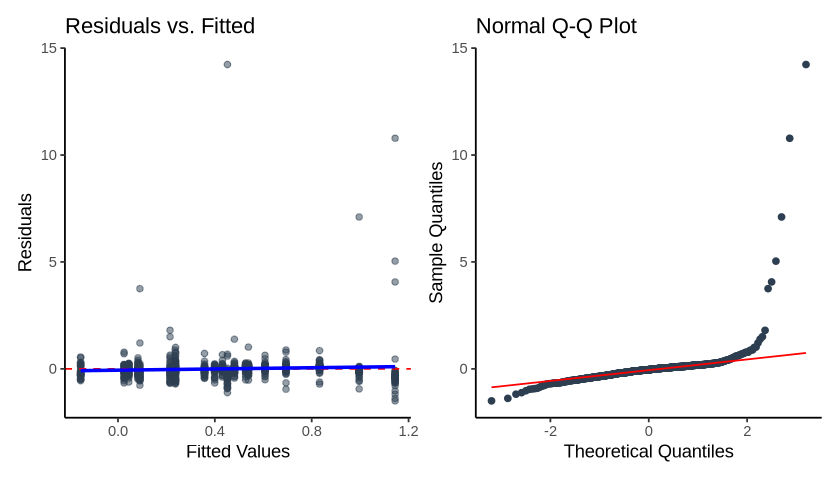

In [34]:
library(lme4)
library(ggplot2)
library(patchwork) # To combine plots

# 1. Fit the final model for BND
final_bnd_model <- lmer(GII_score ~ TL_group + (1 | filename), data = filter(merged_data, type == "BND"))

# 2. Extract residuals and fitted values
diag_data <- data.frame(
  Fitted = predict(final_bnd_model),
  Residuals = residuals(final_bnd_model)
)

# 3. Residuals vs Fitted (Checking for constant variance)
p1 <- ggplot(diag_data, aes(x = Fitted, y = Residuals)) +
  geom_point(alpha = 0.5, color = "#2c3e50") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  geom_smooth(method = "lm", color = "blue", se = FALSE) +
  labs(title = "Residuals vs. Fitted",
       x = "Fitted Values", y = "Residuals") +
  theme_classic()

# 4. Normal Q-Q Plot (Checking for normality)
p2 <- ggplot(diag_data, aes(sample = Residuals)) +
  stat_qq(color = "#2c3e50") +
  stat_qq_line(color = "red") +
  labs(title = "Normal Q-Q Plot",
       x = "Theoretical Quantiles", y = "Sample Quantiles") +
  theme_classic()

# Combine them for the Supplement
p1 + p2


Attaching package: ‘tidyr’


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack




[1] "Correlation consistency across samples:"
# A tibble: 20 × 3
   filename      rho n_arms
   <chr>       <dbl>  <int>
 1 3988     -0.447       38
 2 6285B    -0.351       38
 3 6269C    -0.315       37
 4 6365A    -0.313       28
 5 6500D    -0.115       40
 6 6478A    -0.104       40
 7 6605D    -0.0988      38
 8 6414C    -0.0638      36
 9 6483C    -0.0537      38
10 6266D    -0.0493      29
11 6436B    -0.00405     39
12 3188      0.00300     40
13 6298B     0.0894      38
14 6439C     0.0954      37
15 6423A     0.103       36
16 6314E     0.168       31
17 6265D     0.170       36
18 6324B     0.207       37
19 2436A     0.226       30
20 6277A     0.445       34


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


Observed Rho: -0.08126271 
Permutation P-value: 0.0274 


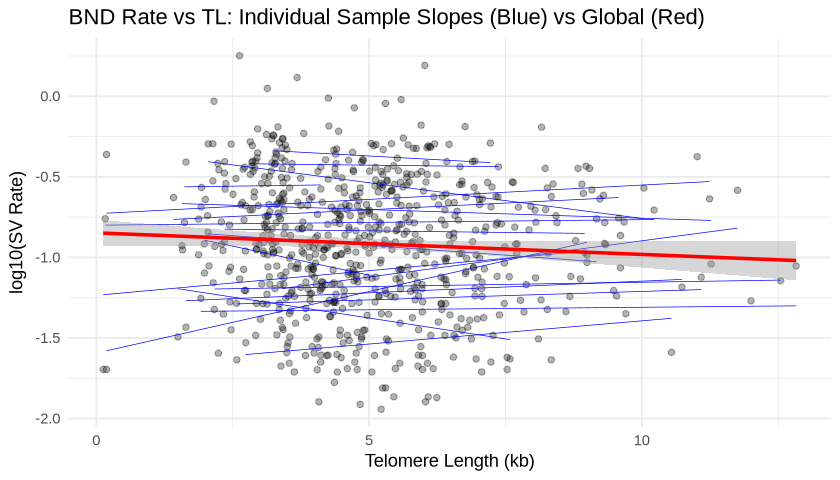

In [35]:
# --- STEP 1: LOAD LIBRARIES AND CLEAN DATA ---
library(dplyr)
library(ggplot2)
library(tidyr)

# Handle zeros and log-transform for visualization
# We use the smallest non-zero value/2 to avoid log(0) issues
min_nonzero <- min(merged_data$sv_rate[merged_data$sv_rate > 0], na.rm = TRUE)
merged_data <- merged_data %>%
  mutate(log_sv_rate = log10(sv_rate + (min_nonzero / 2)))

# --- STEP 2: BY-SAMPLE CONSISTENCY CHECK ---
# Does every patient show a negative correlation, or just a few?
sample_correlations <- merged_data %>%
  filter(type == "BND") %>%
  group_by(filename) %>%
  summarize(
    rho = cor(final_average_TL_p75_kb, sv_rate, method = "spearman", use = "complete.obs"),
    n_arms = n()
  ) %>%
  arrange(rho)

print("Correlation consistency across samples:")
print(sample_correlations)

# Visualize per-sample slopes to detect outliers
ggplot(subset(merged_data, type == "BND"), aes(x = final_average_TL_p75_kb, y = log_sv_rate)) +
  geom_point(alpha = 0.3) +
  geom_smooth(aes(group = filename), method = "lm", se = FALSE, size = 0.2, color = "blue") +
  geom_smooth(method = "lm", color = "red", size = 1) + # Global trend
  labs(title = "BND Rate vs TL: Individual Sample Slopes (Blue) vs Global (Red)",
       x = "Telomere Length (kb)", y = "log10(SV Rate)") +
  theme_minimal()

# --- STEP 3: PERMUTATION TEST (FOR BND) ---
# Testing if p=0.029 is a result of the skewed distribution
observed_rho <- cor(merged_data$final_average_TL_p75_kb[merged_data$type == "BND"], 
                    merged_data$sv_rate[merged_data$type == "BND"], 
                    method = "spearman", use = "complete.obs")

n_permutations <- 5000
permuted_rhos <- numeric(n_permutations)

set.seed(123) # For reproducibility
for(i in 1:n_permutations) {
  # Shuffle TL labels while keeping SV rates fixed
  shuffled_tl <- sample(merged_data$final_average_TL_p75_kb[merged_data$type == "BND"])
  permuted_rhos[i] <- cor(shuffled_tl, 
                          merged_data$sv_rate[merged_data$type == "BND"], 
                          method = "spearman", use = "complete.obs")
}

# Calculate Permutation P-value
perm_p_val <- sum(abs(permuted_rhos) >= abs(observed_rho)) / n_permutations
cat("Observed Rho:", observed_rho, "\nPermutation P-value:", perm_p_val, "\n")

In [36]:
library(dplyr)
library(ggplot2)
library(ggpubr) # For easy p-value brackets

# 1. Filter for BND and ensure TL_group is a factor
bnd_data <- merged_data %>% 
  filter(type == "BND") %>%
  mutate(TL_group = factor(TL_group, levels = c("Other", "Short TL")))

# 2. Perform the Wilcoxon Test (Non-parametric t-test)
wilcox_result <- wilcox.test(sv_rate ~ TL_group, data = bnd_data)
p_val <- wilcox_result$p.value

# 3. Calculate Fold Change for your "Effect Size" argument
stats_summary <- bnd_data %>%
  group_by(TL_group) %>%
  summarize(mean_rate = mean(sv_rate), median_rate = median(sv_rate))

fold_change <- stats_summary$mean_rate[2] / stats_summary$mean_rate[1]

cat("Comparison Results for BND:\n")
cat("Wilcoxon P-value:", p_val, "\n")
cat("Fold Change (Short vs Other):", round(fold_change, 2), "x\n")



Comparison Results for BND:
Wilcoxon P-value: 2.277179e-10 
Fold Change (Short vs Other): 1.61 x


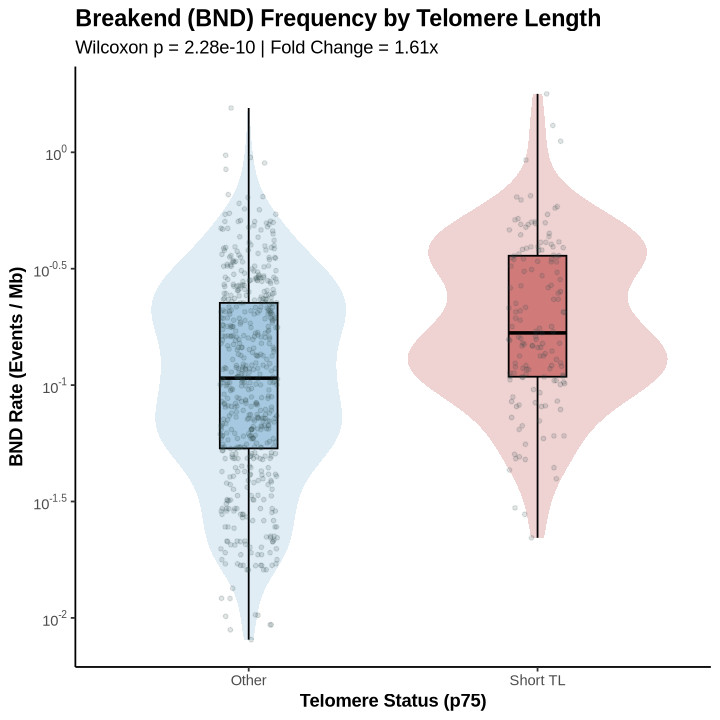

In [21]:
library(ggplot2)
library(ggpubr)

# Ensure BND subset is ready
plot_data <- subset(merged_data, type == "BND")
options(repr.plot.width = 6, repr.plot.height = 6)  # reset if needed

# Create the final publication figure
ggplot(plot_data, aes(x = TL_group, y = sv_rate, fill = TL_group)) +
  # 1. Add half-violin or density to show distribution shape
  geom_violin(alpha = 0.2, color = NA) + 
  # 2. Add boxplot for the quartiles
  geom_boxplot(width = 0.2, outlier.shape = NA, alpha = 0.5, color = "black") +
  # 3. Add jittered points to show every chromosome arm
  geom_jitter(width = 0.1, alpha = 0.15, size = 1, color = "darkslategrey") +
  # 4. Use Log scale for the Y axis (crucial for skewed SV data)
  scale_y_log10(breaks = scales::trans_breaks("log10", function(x) 10^x),
                labels = scales::trans_format("log10", scales::math_format(10^.x))) +
  scale_fill_manual(values = c("Other" = "skyblue3", "Short TL" = "firebrick")) +
  labs(
    title = "Breakend (BND) Frequency by Telomere Length",
    subtitle = "Wilcoxon p = 2.28e-10 | Fold Change = 1.61x",
    x = "Telomere Status (p75)",
    y = "BND Rate (Events / Mb)"
  ) +
  theme_classic() +
  theme(
    legend.position = "none",
    panel.grid.minor = element_blank(),
    axis.title = element_text(face = "bold"),
    plot.title = element_text(size = 14, face = "bold")
  )

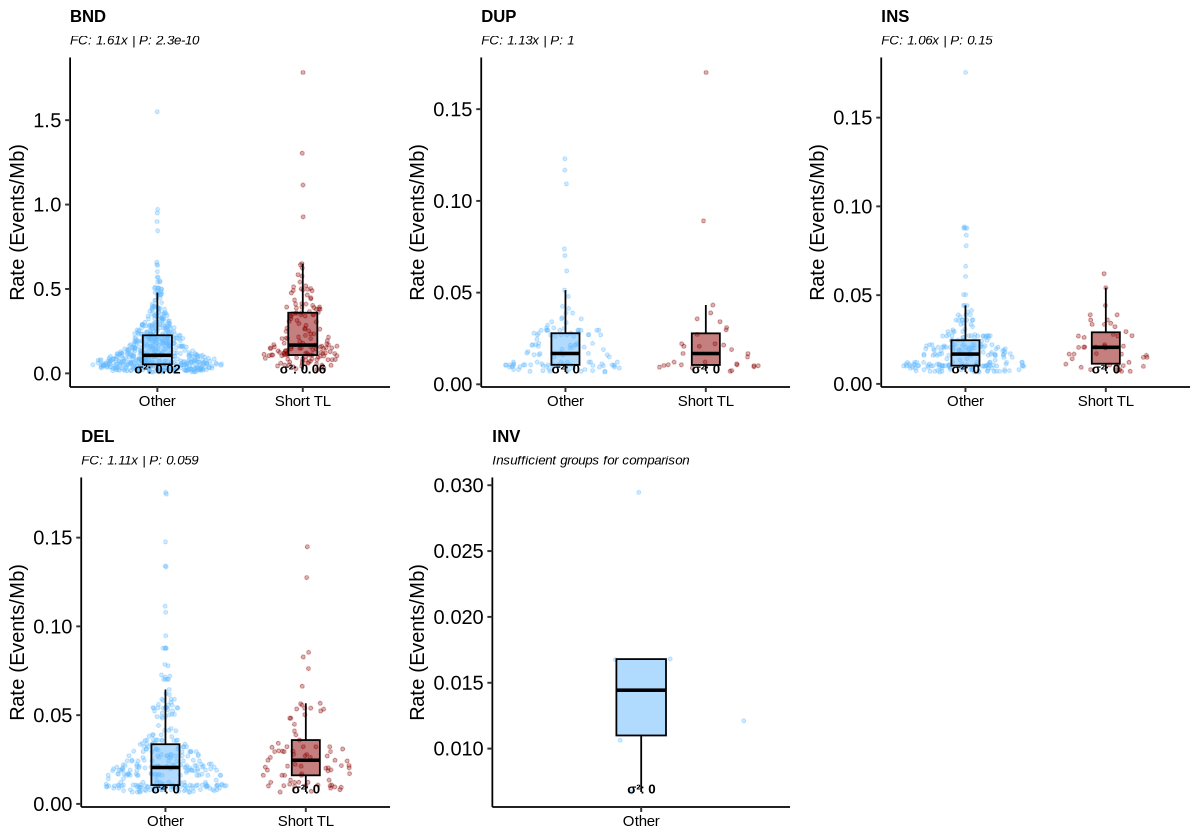

In [48]:
library(dplyr)
library(ggplot2)
library(ggpubr)
library(ggforce)

# 1. Standardize the grouping factor
merged_data$TL_group <- factor(merged_data$TL_group, levels = c("Other", "Short TL"))

# List of genomic types to iterate over (BND, DEL, DUP, etc.)
types_to_plot <- unique(merged_data$type)

# 2. Generate the Analysis & Plotting Loop
plot_list <- lapply(types_to_plot, function(t) {
  
  # Filter for the specific type
  df_sub <- merged_data %>% filter(type == t)
  
  # VALIDATION: Check if we have at least 1 observation in BOTH groups
  group_counts <- table(df_sub$TL_group)
  
  if(all(group_counts > 0)) {
    # A. Calculate Wilcoxon P-value
    wt_res <- wilcox.test(sv_rate ~ TL_group, data = df_sub)
    p_val_text <- format.pval(wt_res$p.value, digits = 2)
    
    # B. Calculate Stats
    stats_summary <- df_sub %>%
      group_by(TL_group) %>%
      summarise(
        mean_rate = mean(sv_rate, na.rm = TRUE),
        variance = var(sv_rate, na.rm = TRUE)
      )
    
    fc <- ifelse(stats_summary$mean_rate[1] > 0, stats_summary$mean_rate[2] / stats_summary$mean_rate[1], Inf)
    subtitle_text <- paste0("FC: ", round(fc, 2), "x | P: ", p_val_text)
    
  } else {
    # Fallback for types missing a group
    stats_summary <- df_sub %>% group_by(TL_group) %>% summarise(variance = var(sv_rate, na.rm = TRUE))
    subtitle_text <- "Insufficient groups for comparison"
  }
options(repr.plot.width = 10, repr.plot.height = 7)  # reset if needed

  # C. The Plot
  p <- ggplot(df_sub, aes(x = TL_group, y = sv_rate, fill = TL_group)) +
    geom_sina(aes(color = TL_group), alpha = 0.3, size = 0.8) +
    geom_boxplot(width = 0.2, outlier.shape = NA, alpha = 0.5, color = "black") +
    
    # Label Variance at the bottom
    geom_text(data = stats_summary, 
              aes(x = TL_group, y = -Inf, label = paste0("σ²: ", round(variance, 2))), 
              vjust = -1.5, size = 2.8, fontface = "bold", inherit.aes = FALSE) +
    
    # Use Log scale for visualization if rates are skewed
    #scale_y_log10(labels = scales::label_log()) +
    
    scale_fill_manual(values = c("Other" = "steelblue1", "Short TL" = "darkred")) +
    scale_color_manual(values = c("Other" = "steelblue1", "Short TL" = "darkred")) +
    
    labs(
      title = t,
      subtitle = subtitle_text,
      y = "Rate (Events/Mb)",
      x = NULL
    ) +
    theme_pubr() + 
    theme(
      legend.position = "none", 
      plot.subtitle = element_text(size = 8, face = "italic"),
      plot.title = element_text(size = 10, face = "bold"),
      axis.text.x = element_text(size = 9)
    )
  
  return(p)
})

# 3. Combine and Print
# Adjust ncol/nrow based on how many 'types' you have
final_sina_figure <- ggarrange(plotlist = plot_list, ncol = 3, nrow = ceiling(length(plot_list)/3))
print(final_sina_figure)

In [49]:
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig3/new_sina_plot.pdf",
  plot = final_sina_figure,
  width = 12,
  height = 8,
  units = "in"
)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'σ²: 0.02' in 'mbcsToSbcs': for σ (U+03C3)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'σ²: 0.06' in 'mbcsToSbcs': for σ (U+03C3)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'σ²: 0' in 'mbcsToSbcs': for σ (U+03C3)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'σ²: 0' in 'mbcsToSbcs': for σ (U+03C3)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'σ²: 0' in 'mbcsToSbcs': for σ (U+03C3)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'σ²: 0' in 'mbcsToSbcs': for σ (U+03C3)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion fai

`geom_smooth()` using formula = 'y ~ x'


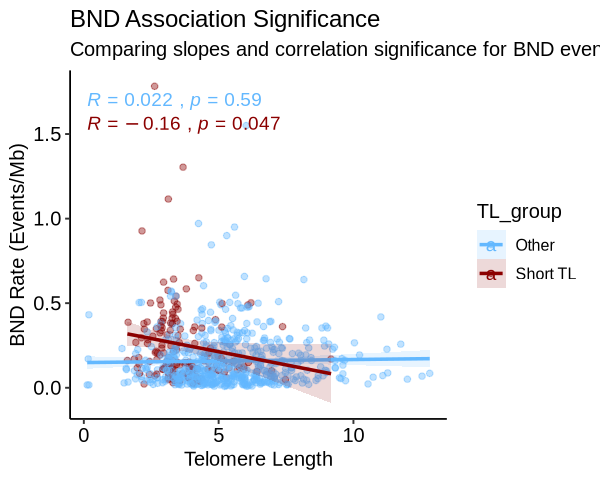

In [57]:
library(dplyr)
library(ggplot2)
library(ggpubr)

# Filter for BND data
bnd_data <- merged_data %>% 
  filter(type == "BND")

# Create the plot with group-specific significance
bnd_sig_plot <- ggplot(bnd_data, aes(x = final_average_TL_p75_kb, y = sv_rate, color = TL_group, fill = TL_group)) +
  geom_point(alpha = 0.4, size = 1.5) +
  geom_smooth(method = "lm", se = TRUE, alpha = 0.15) +
  
  # This adds the R and p-value for each regression line
  stat_cor(aes(label = paste(..r.label.., ..p.label.., sep = "~`,`~")), 
           label.x.npc = "left", label.y.npc = "top", size = 4) +
  
  scale_color_manual(values = c("Other" = "steelblue1", "Short TL" = "darkred")) +
  scale_fill_manual(values = c("Other" = "steelblue1", "Short TL" = "darkred")) +
  labs(
    title = "BND Association Significance",
    subtitle = "Comparing slopes and correlation significance for BND events",
    x = "Telomere Length",
    y = "BND Rate (Events/Mb)"
  ) +
  theme_pubr() +
  theme(legend.position = "right")
options(repr.plot.width = 5, repr.plot.height = 4)  # reset if needed

print(bnd_sig_plot)

In [58]:
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig3/new_correlation_plot.pdf",
  plot = bnd_sig_plot,
  width = 5,
  height = 4,
  units = "in"
)

`geom_smooth()` using formula = 'y ~ x'
